# VITAL Quickstart Tutorial

This notebook provides a minimal end-to-end example of using VITAL to:

1. Load tidal resource data
2. Load rotor performance data
3. Simulate turbine performance
4. Check key constraints
5. Estimate levelized cost of energy (LCOE)

This tutorial is intended as a starting point for new users.

The example uses a representative Sitkana-style battery-charging configuration. More detailed module-specific tutorials and case studies are provided separately.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from vital.module_tidal import process_tidal_data
from vital.module_rotor import RotorData
from vital.module_rotor_simulation import RotorSimulation
from vital.module_vessel import VesselData
from vital.module_constraint_checker import ConstraintChecker
from vital.module_lcoe import LCOEData, LCOECalculator

import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

## 2. Load tidal resource data

This quickstart first attempts to retrieve tidal resource data from NOAA. If NOAA services are unavailable, the workflow can fall back to a local tidal data file.

For this example, both the NOAA station and local fallback dataset correspond to station ``COI0303`` near Port Mackenzie.

The local fallback file should contain at least two columns:

- ``t``: time in seconds
- ``U``: flow speed in m/s

Note that the local file is only used if NOAA retrieval fails. If NOAA succeeds, ``tidal.source`` will be ``"NOAA"`` even when ``local_file`` and ``fallback_metadata`` are provided.

Data source: NOAA
NOAA retrieval succeeded; local fallback file was not used.
Station name: Port Mackenzie, South of
Nearest city: Anchorage
Mooring distance (m): 31.1
Cable length (m): 3970.22
Latitude (deg): 61.25225
Longitude (deg): -149.92067000000003
Number of time points: 336
First 5 flow speeds: [0.61117 1.19754 1.40836 1.00678 0.78511]


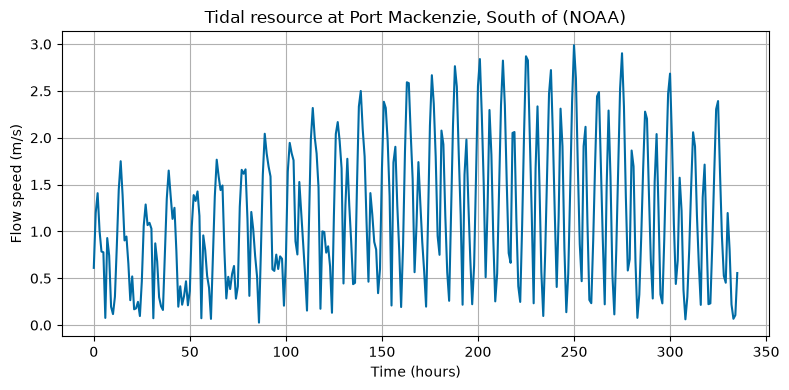

In [2]:
# Load tidal data from NOAA, with a local fallback for reproducibility.
tidal = process_tidal_data(
    station="COI0303",                         # NOAA station ID
    startdate="2021-09-01",                    # Start date, YYYY-MM-DD
    range_hrs=14 * 24,                         # 14 days
    time_step_s=3600,                          # 1-hour time step
    city_data_file="../data/AlaskaCityLatLong.txt",
    local_file="../data/TidalData/COI0303_20210901.txt",
    fallback_metadata={
        "station_name": "COI0303",
        "nearest_city": "Port Mackenzie",
        "latitude_deg": 61.2522,
        "longitude_deg": -149.9207,
        "mooring_distance_m": 50.0,
        "cable_length_m": 1000.0,
    },
)

print("Data source:", tidal.source)
if tidal.source == "local_file":
    print("NOAA retrieval failed; local fallback file was used.")
else:
    print("NOAA retrieval succeeded; local fallback file was not used.")

print("Station name:", tidal.station_name)
print("Nearest city:", tidal.nearest_city)
print("Mooring distance (m):", tidal.mooring_distance)
print("Cable length (m):", tidal.cable_length)
print("Latitude (deg):", np.degrees(tidal.latitude))
print("Longitude (deg):", np.degrees(tidal.longitude))
print("Number of time points:", len(tidal.times))
print("First 5 flow speeds:", tidal.flow_speeds[:5])

# Plot flow speed over time.
plt.figure(figsize=(8, 4))
plt.plot(tidal.times / 3600, tidal.flow_speeds)
plt.xlabel("Time (hours)")
plt.ylabel("Flow speed (m/s)")
plt.title(f"Tidal resource at {tidal.station_name} ({tidal.source})")
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Load and visualize rotor performance data

The rotor performance file provides:

- ``TSR``: tip-speed ratio
- ``Ct``: thrust coefficient
- ``Cq``: torque coefficient

VITAL computes the power coefficient internally as:

$$
C_p = TSR \cdot C_q
$$

If no Cpmin file is supplied, VITAL assumes:

$$
C_{p,\min} = -1.0
$$

The code below loads the rotor data, prints key summary values, and visualizes the performance curves over the measured TSR range.

Optimal Cp: 0.2119
Optimal TSR: 0.7648
Estimated TSRmax: 1.7084
Measured TSR range: 0.0526 to 1.7015


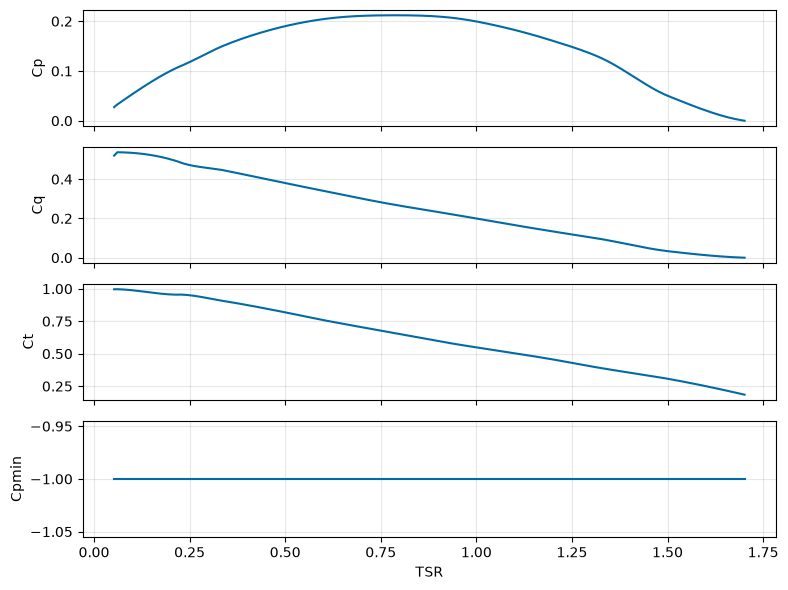

In [3]:
# Load rotor performance data.
rotor = RotorData(
    filename="../data/Sitkana_rotor_data_blade_2.txt",
)

print(f"Optimal Cp: {rotor.CpOpt:.4f}")
print(f"Optimal TSR: {rotor.TSROpt:.4f}")
print(f"Estimated TSRmax: {rotor.TSRmax:.4f}")
print(f"Measured TSR range: {rotor.tsr.min():.4f} to {rotor.tsr.max():.4f}")

# Plot over the measured TSR range.
tsr_vals = np.linspace(rotor.tsr.min(), rotor.tsr.max(), 200)

fig, ax = plt.subplots(4, 1, figsize=(8, 6), sharex=True)

ax[0].plot(tsr_vals, rotor.get_cp(tsr_vals))
ax[0].set_ylabel("Cp")
ax[0].grid(True, alpha=0.3)

ax[1].plot(tsr_vals, rotor.get_cq(tsr_vals))
ax[1].set_ylabel("Cq")
ax[1].grid(True, alpha=0.3)

ax[2].plot(tsr_vals, rotor.get_ct(tsr_vals))
ax[2].set_ylabel("Ct")
ax[2].grid(True, alpha=0.3)

ax[3].plot(tsr_vals, rotor.get_cpmin(tsr_vals))
ax[3].set_ylabel("Cpmin")
ax[3].set_xlabel("TSR")
ax[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Define turbine configuration

This example uses a simple baseline turbine configuration for demonstration. The configuration below connects the tidal resource and rotor performance data to the rotor simulation model.

This quickstart uses the built-in ``simple`` power-conversion model, which requires the generator constants ``Kt`` and ``Rw``.

In [4]:
# Define a simple turbine configuration for the quickstart example.
config = {
    # Turbine geometry and rating
    "Radius": 0.5,                    # Rotor radius (m)
    "Prated": 2500.0,                 # Rated electrical power per turbine (W)
    "Trated": np.inf,                 # Rated generator torque (N m)
    "dHub": 2.0,                      # Hub depth (m)
    "number_of_turbines": 2,

    # Site/time inputs from tidal data
    "dMoor": tidal.mooring_distance,
    "Uinf": tidal.flow_speeds,
    "t": tidal.times,

    # Rotor performance functions
    "CpFunc": rotor.get_cp,
    "CqFunc": rotor.get_cq,
    "CtFunc": rotor.get_ct,
    "CpOpt": rotor.CpOpt,
    "TSROpt": rotor.TSROpt,
    "TSRmax": rotor.TSRmax,

    # Drivetrain and generator parameters
    "Ng": 20,       # Gear ratio between rotor and generator (-)
    "Kt": 1.5,      # Generator torque constant for simple electrical model (N m/A)
    "Rw": 0.5,      # Generator winding resistance for simple electrical model (ohm)
    "J_d": 1.0,     # Drivetrain/generator-side inertia (kg m^2)
    "B_d": 0.01,    # Drivetrain damping/friction coefficient (N m s/rad)
    "J_r": 10.0,    # Rotor inertia (kg m^2)

    # Built-in simple electrical model
    "power_model": "simple",
}

print("Turbine configuration defined.")
print(f"Radius: {config['Radius']} m")
print(f"Rated power: {config['Prated']} W")
print(f"Hub depth: {config['dHub']} m")
print(f"Number of turbines: {config['number_of_turbines']}")

Turbine configuration defined.
Radius: 0.5 m
Rated power: 2500.0 W
Hub depth: 2.0 m
Number of turbines: 2


## 5. Run rotor simulation and visualize outputs

The rotor simulation uses the tidal resource, rotor performance curves, and turbine configuration to estimate turbine speed, torque, thrust, and power over time. The plots below summarize the main simulation outputs.

For the ``simple`` power model, ``Pelec`` is the electrical power output from the built-in generator model.

Solving the initial value problem (IVP) for turbine dynamics...


IVP solving complete.
Rotor simulation complete.
Available result keys: ['t', 'w', 'wr', 'Tg', 'TSR', 'Ft', 'Th', 'dHub', 'Uinf_adjusted', 'Phydro', 'Pfluid', 'Punc', 'Pmech', 'Pelec', 'Pac', 'Pbat', 'Pgen_loss', 'Ppe_loss', 'Iq', 'Vq', 'power_model']


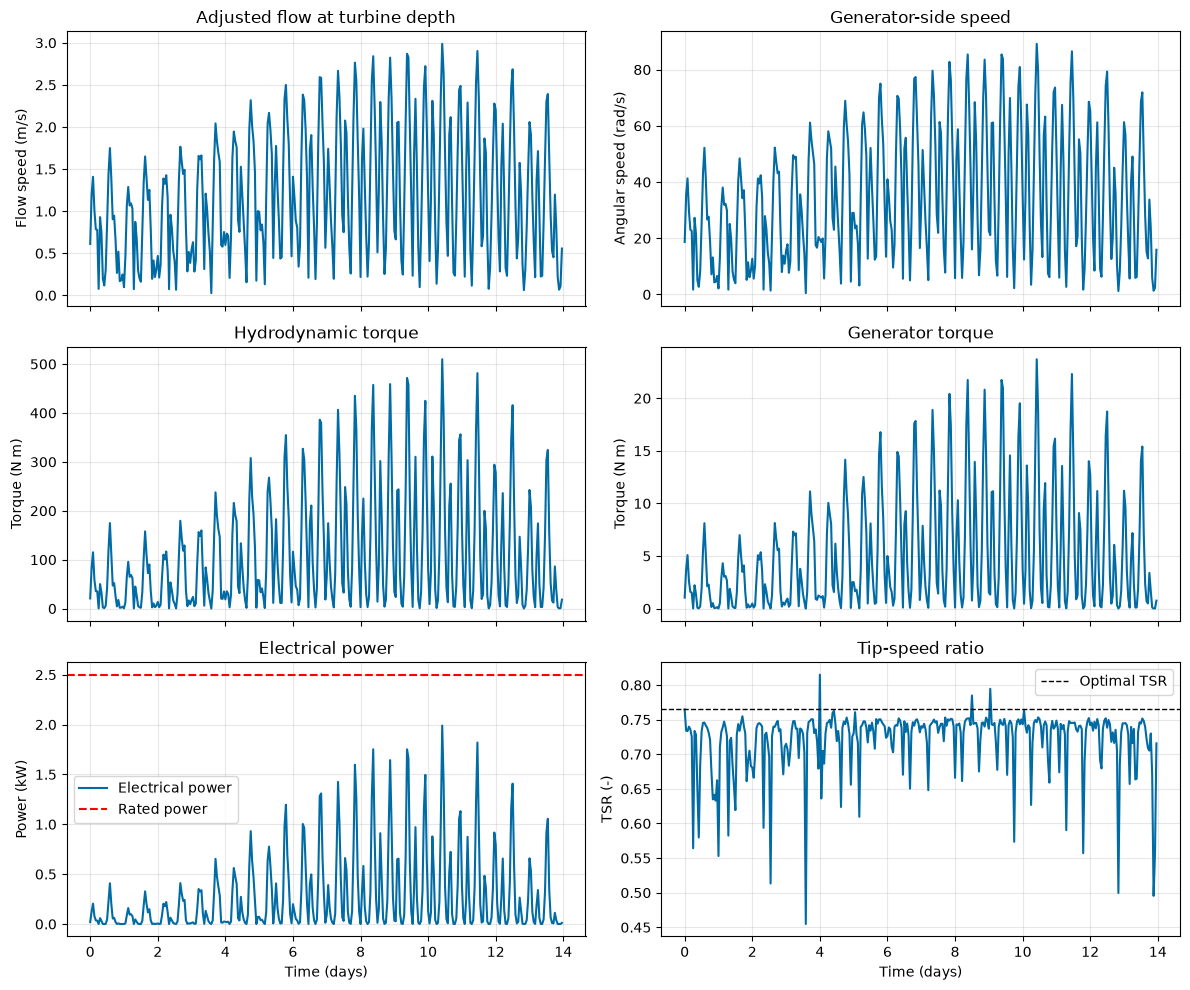

In [5]:
# Create and run the rotor simulation.
rotor_sim = RotorSimulation(config)
rotor_sim.simulate()
result = rotor_sim.get_results()

print("Rotor simulation complete.")
print("Available result keys:", list(result.keys()))

# Convert simulation time from seconds to days for plotting.
time_days = result["t"] / (24 * 3600)

fig, ax = plt.subplots(3, 2, figsize=(12, 10), sharex=True)

# Adjusted flow speed at turbine depth.
ax[0, 0].plot(time_days, result["Uinf_adjusted"])
ax[0, 0].set_ylabel("Flow speed (m/s)")
ax[0, 0].set_title("Adjusted flow at turbine depth")
ax[0, 0].grid(True, alpha=0.3)

# Generator-side angular speed.
ax[0, 1].plot(time_days, result["w"])
ax[0, 1].set_ylabel("Angular speed (rad/s)")
ax[0, 1].set_title("Generator-side speed")
ax[0, 1].grid(True, alpha=0.3)

# Hydrodynamic torque from the rotor.
ax[1, 0].plot(time_days, result["Th"])
ax[1, 0].set_ylabel("Torque (N m)")
ax[1, 0].set_title("Hydrodynamic torque")
ax[1, 0].grid(True, alpha=0.3)

# Generator torque applied by the controller.
ax[1, 1].plot(time_days, result["Tg"])
ax[1, 1].set_ylabel("Torque (N m)")
ax[1, 1].set_title("Generator torque")
ax[1, 1].grid(True, alpha=0.3)

# Electrical power from the simple generator model.
ax[2, 0].plot(time_days, result["Pelec"] / 1000, label="Electrical power")
ax[2, 0].axhline(
    config["Prated"] / 1000,
    color="r",
    linestyle="--",
    label="Rated power",
)
ax[2, 0].set_ylabel("Power (kW)")
ax[2, 0].set_title("Electrical power")
ax[2, 0].set_xlabel("Time (days)")
ax[2, 0].grid(True, alpha=0.3)
ax[2, 0].legend()

# Tip-speed ratio.
ax[2, 1].plot(time_days, result["TSR"])
ax[2, 1].axhline(
    config["TSROpt"],
    color="k",
    linestyle="--",
    linewidth=1,
    label="Optimal TSR",
)
ax[2, 1].set_ylabel("TSR (-)")
ax[2, 1].set_title("Tip-speed ratio")
ax[2, 1].set_xlabel("Time (days)")
ax[2, 1].grid(True, alpha=0.3)
ax[2, 1].legend()

plt.tight_layout()
plt.show()

## 6. Define representative vessel properties

The vessel properties below represent a simplified, user-defined example for constraint checking and LCOE estimation. Users may replace these values with site- or vessel-specific data.

Maximum vessel drag force: 43473.27 N
Mean vessel drag force: 9434.72 N


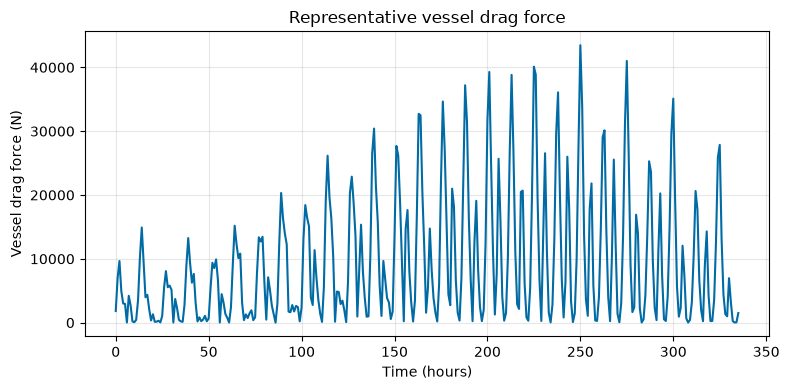

In [6]:
# Define representative vessel/platform properties for drag and pitch checks.
user_vessel_properties = {
    "Xm": 5.77,                    # Horizontal force-application distance (m)
    "Zm": 1.65,                    # Vertical force-application distance (m)
    "Kphi": 1.95e6,                # Pitch hydrostatic stiffness (N m/rad)
    "theta": np.deg2rad(45.0),     # Mooring line angle (rad)
    "phi": np.deg2rad(20.0),       # Representative pitch angle (rad)
    "area": 9.5,                   # Projected/cross-sectional area (m^2)
    "Cd": 1.0,                     # Drag coefficient (-)
}

# Create vessel object and compute drag using adjusted flow from the simulation.
vessel = VesselData(
    user_defined=True,
    vessel_properties=user_vessel_properties,
    simResult=result,
)

print(f"Maximum vessel drag force: {np.max(vessel.Fdrag):.2f} N")
print(f"Mean vessel drag force: {np.mean(vessel.Fdrag):.2f} N")

# Plot vessel drag over time.
plt.figure(figsize=(8, 4))
plt.plot(result["t"] / 3600, vessel.Fdrag)
plt.xlabel("Time (hours)")
plt.ylabel("Vessel drag force (N)")
plt.title("Representative vessel drag force")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Check constraints

The constraint checker evaluates whether the turbine and vessel configuration satisfies key operating limits, including power, depth, cavitation, and pitch stability constraints.

In [7]:
# Check whether the simulated design satisfies key operating constraints.
constraint_checker = ConstraintChecker(rotor, config, vessel, result)

constraints = {
    "Power Constraint": constraint_checker.check_power_constraint(),          # 0 <= Pelec <= Prated
    "Depth Constraint": constraint_checker.check_depth_constraint(),          # dHub - Radius > 0
    "Cavitation Constraint": constraint_checker.check_cavitation_constraint(),
    "Pitch Constraint": constraint_checker.check_pitch_constraint(),
}

print("Constraint Results:")
for name, satisfied in constraints.items():
    status = "Satisfied" if satisfied else "Not Satisfied"
    print(f"  {name}: {status}")

# Print margins to show how close the design is to each constraint limit.
print()
print("Constraint margins:")
print(f"  Minimum power margin, Prated - Pelec: {np.min(constraint_checker.power_constraint()):.3f} W")
print(f"  Depth margin, dHub - Radius: {constraint_checker.depth_constraint():.3f} m")
print(f"  Minimum cavitation margin: {np.min(constraint_checker.cavitation_constraint()):.3f} Pa")
print(f"  Minimum pitch margin: {np.min(constraint_checker.pitch_constraint()):.3f} N m")

if not all(constraints.values()):
    print()
    print(
        "Warning: One or more constraints are not satisfied. "
        "LCOE can still be calculated, but the design should be treated as infeasible."
    )

Constraint Results:
  Power Constraint: Satisfied
  Depth Constraint: Satisfied
  Cavitation Constraint: Satisfied
  Pitch Constraint: Satisfied

Constraint margins:
  Minimum power margin, Prated - Pelec: 509.993 W
  Depth margin, dHub - Radius: 1.500 m
  Minimum cavitation margin: 106203.707 Pa
  Minimum pitch margin: 417182.893 N m


## 8. Estimate LCOE

The LCOE calculation combines the tidal resource, turbine configuration, vessel properties, and simulation results to estimate annual energy production and levelized cost of energy.

This quickstart uses:

```python
customer = "customer_B"
application = "battery_charging"
BatteryCapacity_kWh = 10.0
```

Because this is a battery-charging application, ``BatteryCapacity_kWh`` must be provided and must be greater than zero.

In [8]:
# Create the LCOE input data object.
data = LCOEData(
    tidalData=tidal,
    turbineConfig=config,
    vesselData=vessel,
    simResult=result,
    lifetime=10,                    # Project lifetime (years)
    discount_rate=0.1,              # Discount rate (-)
    turbulence_intensity=0.0,       # Turbulence intensity (-)
    customer="customer_B",          # Cost configuration
    application="battery_charging", # Application type
    BatteryCapacity_kWh=10.0,       # Battery capacity (kWh)
)

# Calculate cost and energy metrics.
calculator = LCOECalculator(data)

total_capex = calculator.calculate_total_capex()          # USD
total_opex = calculator.calculate_total_opex(total_capex) # USD/year
annual_energy = calculator.calculate_annual_energy()      # kWh/year
lcoe = calculator.calculate_lcoe()                        # USD/kWh

print(f"LCOE: ${lcoe:.4f}/kWh")
print(f"Annual energy: {annual_energy:.2f} kWh/year")
print(f"Total CAPEX: ${total_capex:,.2f}")
print(f"Total OPEX: ${total_opex:,.2f} per year")

LCOE: $0.2111/kWh
Annual energy: 4956.16 kWh/year
Total CAPEX: $5,161.54
Total OPEX: $206.46 per year


## 9. Show cost breakdown

The cost breakdown shows the main CAPEX and OPEX components used in the LCOE calculation, along with the annual energy estimate.

In [9]:
calculator.list_capex()
calculator.list_opex(total_capex)
calculator.list_annual_energy()

CAPEX Components:
  anchor_cost: $206.31
  gearbox_cost: $593.10
  concrete_cost: $27.53
  assembly_cost: $462.00
  generator_cost: $1316.50
  rotor_cost: $3.55
  steel_component_cost: $220.36
  rotor_construction_cost: $6.59
  battery_cost: $1500.00
  charge_controller_cost: $825.60
Total component CAPEX: $5161.54
Adjustment factor: 1.00
Adjusted CAPEX: $5161.54
OPEX Components:
  SITKANA Operating Cost: $206.46
Total OPEX: $206.46
Annual Energy Generation: 4956.16 kWh


## 10. Summary

This tutorial demonstrated a basic VITAL workflow, including:

- loading and using resource data
- loading and visualizing rotor performance curves
- running a turbine simulation using a representative configuration
- checking vessel and operating constraints
- estimating LCOE and reporting cost breakdowns

This workflow is designed to be adaptable to different resource sites, rotor performance curves, vessel configurations, and cost-model assumptions.